# **Heart Disease Prediction Using a Hybrid Feature Selection and Ensemble Learning Approach**<br>

## [Kelompok 5] Project Data Science KOM

Anggota Kelompok:<br>
Mikail Achmad (24/542370/PA/23026)<br>
Marco Christian	(24/539714/PA/22915)<br>
Thufail Bahir Al Bariq	(24/537843/PA/22801)<br>
Erdizah Ghodi Al Haidar	(24/537670/PA/22787)<br>

In [1]:
import os
import random
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler

from sklearn.ensemble import RandomForestClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, ReLU, MaxPooling1D
from tensorflow.keras.layers import Dense, Flatten

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

GLOBAL_SEED = 42
os.environ["PYTHONHASHSEED"] = str(GLOBAL_SEED)
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
tf.random.set_seed(GLOBAL_SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

In [2]:
PATH = './dataset/heart_disease_cleveland.csv'
df = pd.read_csv(PATH)

## EDA

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [4]:
df.shape

(303, 14)

In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


## Exploratory Data Analysis

In [7]:
# Paper mendefinisikan 'target' sebagai indikator biner (0 = tidak ada penyakit jantung, 1 = ada penyakit jantung).
df["target"].value_counts().sort_index()

target
0    164
1    139
Name: count, dtype: int64

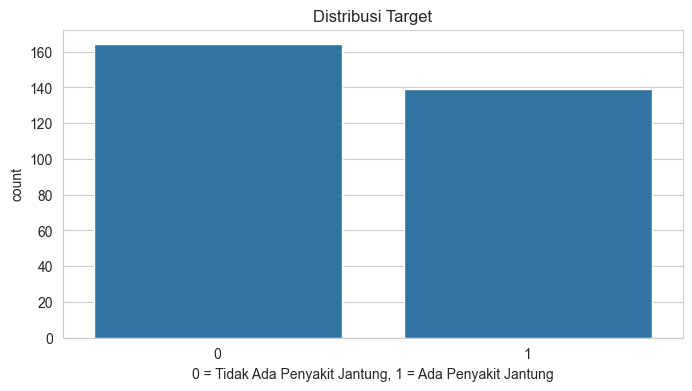

In [8]:
sns.countplot(data=df, x="target")
plt.title("Distribusi Target")
plt.xlabel("0 = Tidak Ada Penyakit Jantung, 1 = Ada Penyakit Jantung")
plt.show()

In [9]:
# Cek missing values
df.isnull().sum().sort_values(ascending=False)

ca          4
thal        2
cp          0
trestbps    0
age         0
sex         0
fbs         0
chol        0
restecg     0
thalach     0
oldpeak     0
exang       0
slope       0
target      0
dtype: int64

In [10]:
# Cek duplikat
df.duplicated().sum()

np.int64(0)

In [11]:
# Cek nilai 0 yang secara medis tidak valid
df[["trestbps", "chol"]].eq(0).sum()

trestbps    0
chol        0
dtype: int64

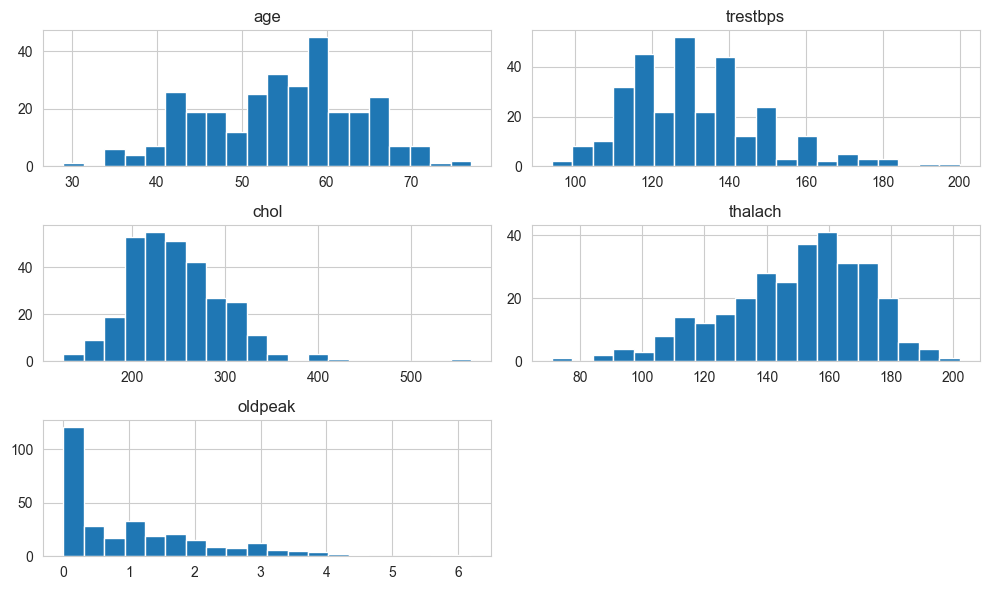

In [12]:
numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]
df[numeric_cols].hist(figsize=(10, 6), bins=20)
plt.tight_layout()
plt.show()

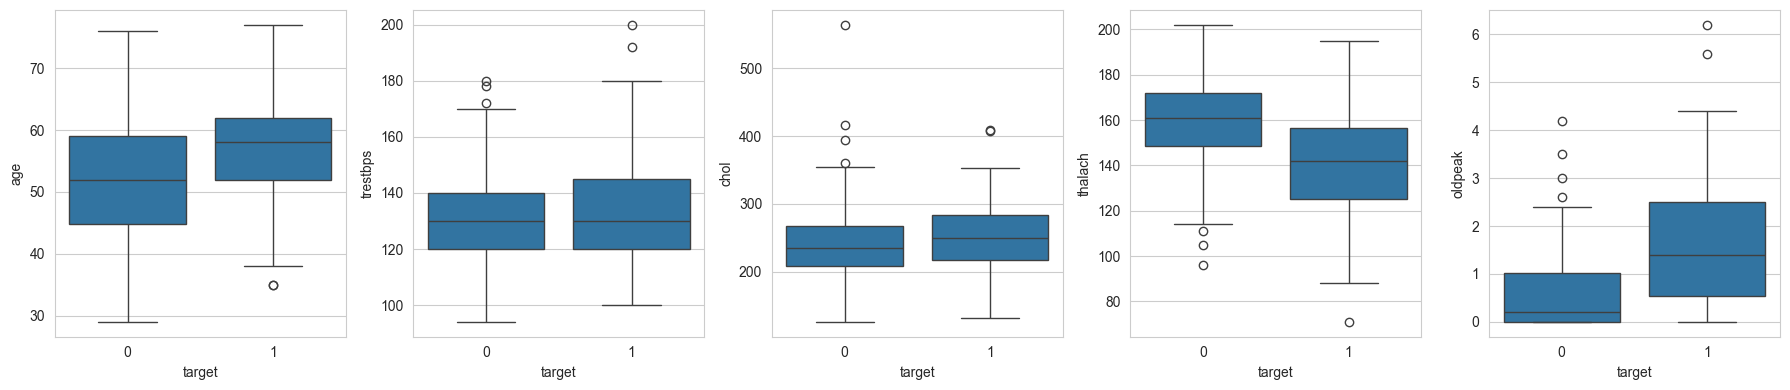

In [13]:
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(18, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, x="target", y=col, ax=ax)
plt.tight_layout()
plt.show()

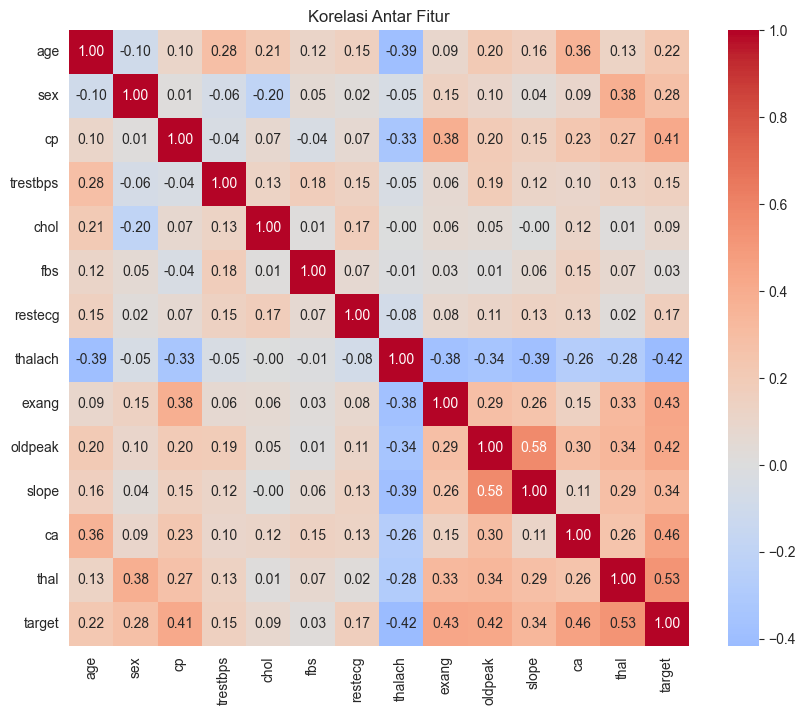

In [14]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Korelasi Antar Fitur")
plt.show()

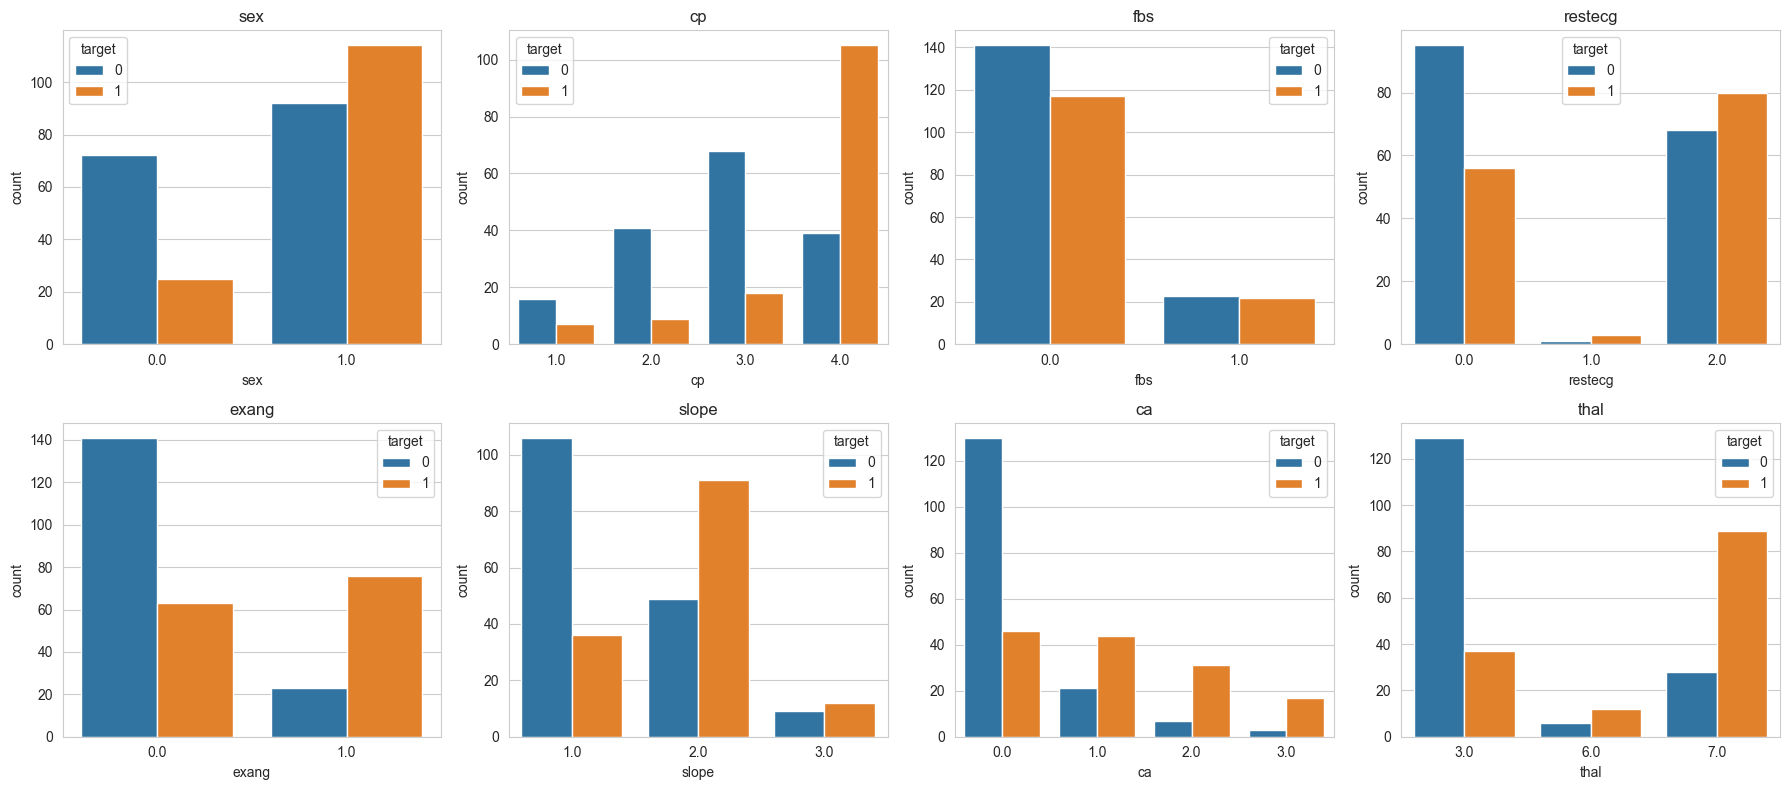

In [15]:
categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), categorical_cols):
    sns.countplot(data=df, x=col, hue="target", ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Preprocessing

In [16]:
# harmonize target column name to match the paper's 'Num' (0 = no disease, 1 = disease)
target_col = "target" if "target" in df.columns else df.columns[-1]
df = df.rename(columns={target_col: "num"})
TARGET = 'num'

print(df.shape)
df.head()

(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [17]:
feature_cols = [c for c in df.columns if c != TARGET]
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_cols = [c for c in feature_cols if c not in continuous_cols]

train_df, test_df = train_test_split(df, test_size=0.2, random_state=GLOBAL_SEED,
                                     stratify=df[TARGET])
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
print('Train:', train_df.shape, '| Test:', test_df.shape)
print('Distribusi kelas train:', train_df[TARGET].value_counts().to_dict())

Train: (242, 14) | Test: (61, 14)
Distribusi kelas train: {0: 131, 1: 111}


In [18]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OneHotEncoder

NOMINAL_COLS = ['cp', 'restecg', 'slope', 'thal', 'ca']  # ASUMSI: nominal (bukan ordinal) -> one-hot
BINARY_COLS  = ['sex', 'fbs', 'exang']                   # biner: tetap Min-Max (0/1, tidak ada ordering palsu)
LOG_COLS     = ['chol', 'oldpeak']                       # skew > 1 (lihat preprocessing_improvement.ipynb bagian 2.1)

class IQRClipper(BaseEstimator, TransformerMixin):
    """Winsorize dengan batas IQR (baris TIDAK dihapus). Batas dihitung dari data fit (train saja)."""
    def __init__(self, k=1.5):
        self.k = k
    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        q1, q3 = np.nanpercentile(X, 25, axis=0), np.nanpercentile(X, 75, axis=0)
        iqr = q3 - q1
        self.lo_, self.hi_ = q1 - self.k * iqr, q3 + self.k * iqr
        return self
    def transform(self, X):
        return np.clip(np.asarray(X, dtype=float), self.lo_, self.hi_)

# Imputasi (median untuk kontinu, modus untuk kategorikal)
num_imp = SimpleImputer(strategy='median')
cat_imp = SimpleImputer(strategy='most_frequent')
train_df[continuous_cols] = num_imp.fit_transform(train_df[continuous_cols])
test_df[continuous_cols]  = num_imp.transform(test_df[continuous_cols])
train_df[categorical_cols] = cat_imp.fit_transform(train_df[categorical_cols])
test_df[categorical_cols]  = cat_imp.transform(test_df[categorical_cols])
n_rows = len(train_df)

# Log1p pada kolom skew (transformasi monoton, dilakukan sebelum clipping & scaling)
for c in LOG_COLS:
    train_df[c] = np.log1p(train_df[c])
    test_df[c]  = np.log1p(test_df[c])

# IQR clipping (winsorize): batas dari TRAIN saja, baris TIDAK dibuang (beda dari versi sebelumnya
# yang menghapus baris outlier dari train -> ukuran sampel train kini tetap penuh)
clipper = IQRClipper()
train_df[continuous_cols] = clipper.fit_transform(train_df[continuous_cols])
test_df[continuous_cols]  = clipper.transform(test_df[continuous_cols])
print(f'Baris train dipertahankan: {n_rows} (outlier di-clip/winsorize, bukan dihapus)')

# One-hot encoding untuk kolom nominal (menghilangkan ordering palsu antar-kategori)
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
nom_names = list(ohe.fit(train_df[NOMINAL_COLS]).get_feature_names_out(NOMINAL_COLS))
train_nom = pd.DataFrame(ohe.transform(train_df[NOMINAL_COLS]), columns=nom_names, index=train_df.index)
test_nom  = pd.DataFrame(ohe.transform(test_df[NOMINAL_COLS]),  columns=nom_names, index=test_df.index)

# Min-Max scaling (fit di train) untuk kolom kontinu + biner; kolom nominal sudah 0/1 dari one-hot
scale_cols = continuous_cols + BINARY_COLS
scaler = MinMaxScaler()
train_df[scale_cols] = scaler.fit_transform(train_df[scale_cols])
test_df[scale_cols]  = scaler.transform(test_df[scale_cols])

train_df = pd.concat([train_df.drop(columns=NOMINAL_COLS), train_nom], axis=1)
test_df  = pd.concat([test_df.drop(columns=NOMINAL_COLS),  test_nom],  axis=1)

feature_cols = continuous_cols + BINARY_COLS + nom_names  # diperbarui: nominal sekarang one-hot

X_train = train_df[feature_cols].to_numpy(dtype=float)
y_train = train_df[TARGET].to_numpy(dtype=int)
X_test  = test_df[feature_cols].to_numpy(dtype=float)
y_test  = test_df[TARGET].to_numpy(dtype=int)
n_features = X_train.shape[1]

X, y = X_train, y_train

assert not np.isnan(X_train).any() and not np.isnan(X_test).any()
print('X_train:', X_train.shape, '| X_test:', X_test.shape)
print('feature_cols (setelah one-hot):', feature_cols)

Baris train dipertahankan: 242 (outlier di-clip/winsorize, bukan dihapus)
X_train: (242, 25) | X_test: (61, 25)
feature_cols (setelah one-hot): ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'sex', 'fbs', 'exang', 'cp_1.0', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'restecg_0.0', 'restecg_1.0', 'restecg_2.0', 'slope_1.0', 'slope_2.0', 'slope_3.0', 'thal_3.0', 'thal_6.0', 'thal_7.0', 'ca_0.0', 'ca_1.0', 'ca_2.0', 'ca_3.0']


# Feature Extraction

## 4. Fitness function (wrapper method)

In [19]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier

In [20]:
RNG_SEED = GLOBAL_SEED 
rng = np.random.default_rng(RNG_SEED)

_fitness_cache = {}
_clf_template = dict(n_estimators=10, max_depth=5, n_jobs=1, random_state=RNG_SEED)
_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RNG_SEED)


def sigmoid(v):
    return 1 / (1 + np.exp(-v))


def to_binary_mask(vec):
    '''Continuous search vector -> boolean feature mask via sigmoid thresholding.'''
    probs = sigmoid(vec)
    mask = probs > 0.5
    if not mask.any():  # never allow the empty subset
        mask[np.argmax(probs)] = True
    return mask


def objective_value(vec) -> float:
    '''Lower is better (this is what the paper's Fig. 3 plots).'''
    mask = to_binary_mask(vec)
    key = mask.tobytes()
    if key in _fitness_cache:
        return _fitness_cache[key]

    Xs = X[:, mask]
    acc = cross_val_score(
        RandomForestClassifier(**_clf_template), Xs, y, cv=_cv, scoring="accuracy"
    ).mean()

    frac_selected = mask.sum() / len(mask)
    obj = 100.0 * ((1 - acc) + 0.01 * frac_selected)
    _fitness_cache[key] = obj
    return obj


def fitness_from_objective(obj):
    '''Higher is better; used where an algorithm expects a fitness to maximize.'''
    return -obj


## 5. Standalone Genetic Algorithm (paper, Section IV-A-1)

In [21]:

def genetic_algorithm(n_dims, pop_size=10, generations=20,
                       crossover_prob=0.9, mutation_prob=0.05,
                       objective_fn=objective_value, seed=RNG_SEED):
    if objective_fn is None:
        objective_fn = objective_value  # default: feature-selection objective

    local_rng = np.random.default_rng(seed)
    population = local_rng.uniform(-1, 1, size=(pop_size, n_dims))  # FIX: pakai n_dims, bukan n_features
    history = []

    def evaluate(pop):
        return np.array([objective_fn(ind) for ind in pop])  # FIX: pakai objective_fn, bukan objective_value hardcoded

    obj_vals = evaluate(population)
    best_idx = obj_vals.argmin()
    best_vec, best_obj = population[best_idx].copy(), obj_vals[best_idx]
    history.append(best_obj)

    for _ in range(generations):
        fitness = fitness_from_objective(obj_vals)
        fitness_shifted = fitness - fitness.min() + 1e-6  # roulette needs positives
        probs = fitness_shifted / fitness_shifted.sum()

        # 1) Selection (roulette wheel)
        parents_idx = local_rng.choice(pop_size, size=pop_size, p=probs)
        parents = population[parents_idx]

        # 2) Crossover (single-point)
        children = parents.copy()
        for i in range(0, pop_size - 1, 2):
            if local_rng.random() < crossover_prob:
                point = local_rng.integers(1, n_dims)  # FIX: pakai n_dims, bukan n_features
                children[i, point:], children[i + 1, point:] = (
                    parents[i + 1, point:].copy(), parents[i, point:].copy(),
                )

        # 3) Mutation
        mut_mask = local_rng.random(children.shape) < mutation_prob
        children[mut_mask] += local_rng.normal(0, 0.5, size=mut_mask.sum())

        # 4) Replacement (elitism: keep the best individual seen so far)
        children[0] = best_vec
        population = children

        obj_vals = evaluate(population)
        gen_best_idx = obj_vals.argmin()
        if obj_vals[gen_best_idx] < best_obj:
            best_obj, best_vec = obj_vals[gen_best_idx], population[gen_best_idx].copy()
        history.append(best_obj)

    return best_vec, best_obj, history


ga_best_vec, ga_best_obj, ga_history = genetic_algorithm(n_features)
print(f"GA best objective: {ga_best_obj:.3f}")
print(f"GA selected features: {[f for f,m in zip(feature_cols, to_binary_mask(ga_best_vec)) if m]}")


GA best objective: 15.578
GA selected features: ['exang', 'cp_4.0', 'restecg_2.0', 'slope_1.0', 'thal_3.0', 'ca_0.0', 'ca_1.0']


## 6. Standalone Cuckoo Search Algorithm (paper, Section IV-A-2)

In [22]:

def levy_flight(shape, beta=1.5, rng=rng):
    # Mantegna's algorithm for Levy-distributed steps
    num = math.gamma(1 + beta) * np.sin(np.pi * beta / 2)
    den = math.gamma((1 + beta) / 2) * beta * 2 ** ((beta - 1) / 2)
    sigma_u = (num / den) ** (1 / beta)
    u = rng.normal(0, sigma_u, size=shape)
    v = rng.normal(0, 1, size=shape)
    return u / (np.abs(v) ** (1 / beta))


# PATCH: n_nests/iterations restored to paper Table 2 / Sec. IV-A-2 (50 nest, 100 iterasi)
# (was 15/20 in this notebook -- an unintentionally reduced search budget that starved
# CSA/Hybrid of exploration relative to the paper's design).
def cuckoo_search(n_features, n_nests=50, iterations=100, pa=0.25, levy_lambda=1.5,
                   seed=RNG_SEED):
    local_rng = np.random.default_rng(seed)
    nests = local_rng.uniform(-1, 1, size=(n_nests, n_features))
    obj_vals = np.array([objective_value(n) for n in nests])
    best_idx = obj_vals.argmin()
    best_vec, best_obj = nests[best_idx].copy(), obj_vals[best_idx]
    history = [best_obj]

    for _ in range(iterations):
        # Levy-flight guided new solutions
        step = levy_flight(nests.shape, beta=levy_lambda, rng=local_rng)
        new_nests = nests + 0.01 * step * (nests - best_vec)
        new_obj = np.array([objective_value(n) for n in new_nests])

        improved = new_obj < obj_vals
        nests[improved] = new_nests[improved]
        obj_vals[improved] = new_obj[improved]

        # a fraction pa of the worst nests are abandoned and rebuilt randomly
        n_abandon = int(pa * n_nests)
        worst_idx = np.argsort(obj_vals)[-n_abandon:]
        nests[worst_idx] = local_rng.uniform(-1, 1, size=(n_abandon, n_features))
        obj_vals[worst_idx] = [objective_value(n) for n in nests[worst_idx]]

        gen_best_idx = obj_vals.argmin()
        if obj_vals[gen_best_idx] < best_obj:
            best_obj, best_vec = obj_vals[gen_best_idx], nests[gen_best_idx].copy()
        history.append(best_obj)

    return best_vec, best_obj, history


csa_best_vec, csa_best_obj, csa_history = cuckoo_search(n_features)
print(f"CSA best objective: {csa_best_obj:.3f}")
print(f"CSA selected features: {[f for f,m in zip(feature_cols, to_binary_mask(csa_best_vec)) if m]}")


CSA best objective: 15.422
CSA selected features: ['age', 'chol', 'sex', 'fbs', 'cp_1.0', 'cp_2.0', 'cp_4.0', 'restecg_0.0', 'slope_1.0', 'slope_3.0', 'thal_3.0', 'thal_6.0', 'ca_1.0']


## 7. Hybrid GA + CSO (paper, *Algorithm 1*)

In [23]:

# PATCH: pop_size/generations restored to paper Table 2 / Algorithm 1 (pop 50, gen 100)
# (was 15/20 -- this alone is the main reason Hybrid GA+CSO wasn't converging to the
# lowest objective: it had less search budget than CSA and barely more than GA).
def hybrid_ga_cso(n_features, pop_size=50, generations=100, mutation_prob=0.05,
                   random_walk_prob=0.25, crossover_prob=0.9, delta=5,
                   levy_lambda=1.5, seed=RNG_SEED):
    local_rng = np.random.default_rng(seed)
    population = local_rng.uniform(-1, 1, size=(pop_size, n_features))

    obj_vals = np.array([objective_value(ind) for ind in population])
    best_idx = obj_vals.argmin()
    gbest_vec, gbest_obj = population[best_idx].copy(), obj_vals[best_idx]
    history = [gbest_obj]
    stagnant_count = 0

    for _ in range(generations):
        # (3) fitness already computed as obj_vals from previous iteration

        # (4-6) Levy-flight-based update toward the global best, then refresh gbest
        step = levy_flight(population.shape, beta=levy_lambda, rng=local_rng)
        alpha = 0.01
        population = population + alpha * step * (population - gbest_vec)

        obj_vals = np.array([objective_value(ind) for ind in population])
        gen_best_idx = obj_vals.argmin()
        if obj_vals[gen_best_idx] < gbest_obj:
            gbest_obj, gbest_vec = obj_vals[gen_best_idx], population[gen_best_idx].copy()

        # (7-11) random-walk step for a random subset of individuals, then repair + re-evaluate
        do_walk = local_rng.random(pop_size) < random_walk_prob  # PATCH: aligned with reference formula
        idx_pool = np.arange(pop_size)
        for i in np.where(do_walk)[0]:
            xk, xj = population[local_rng.choice(idx_pool, 2, replace=False)]
            population[i] = population[i] + local_rng.random() * (xk - xj)
        population = np.clip(population, -3, 3)  # "repair the solution"
        obj_vals = np.array([objective_value(ind) for ind in population])

        # (12) update global best again after the random-walk pass
        gen_best_idx = obj_vals.argmin()
        if obj_vals[gen_best_idx] < gbest_obj:
            gbest_obj, gbest_vec = obj_vals[gen_best_idx], population[gen_best_idx].copy()
            stagnant_count = 0
        else:
            stagnant_count += 1

        # (13-14) swap mutation if global best hasn't improved for `delta` generations
        if stagnant_count >= delta:
            mut_idx = local_rng.integers(0, pop_size)
            i, j = local_rng.choice(n_features, 2, replace=False)
            population[mut_idx, [i, j]] = population[mut_idx, [j, i]]
            if local_rng.random() < mutation_prob:
                population[mut_idx] += local_rng.normal(0, 0.5, size=n_features)
            stagnant_count = 0

        # (15) final evaluate/update pass for this generation
        obj_vals = np.array([objective_value(ind) for ind in population])
        gen_best_idx = obj_vals.argmin()
        if obj_vals[gen_best_idx] < gbest_obj:
            gbest_obj, gbest_vec = obj_vals[gen_best_idx], population[gen_best_idx].copy()

        history.append(gbest_obj)

    return gbest_vec, gbest_obj, history  # (16) final solution


hybrid_best_vec, hybrid_best_obj, hybrid_history = hybrid_ga_cso(n_features)
print(f"Hybrid GA+CSO best objective: {hybrid_best_obj:.3f}")
print(f"Hybrid selected features: {[f for f,m in zip(feature_cols, to_binary_mask(hybrid_best_vec)) if m]}")


Hybrid GA+CSO best objective: 14.092
Hybrid selected features: ['thalach', 'fbs', 'cp_1.0', 'cp_4.0', 'restecg_0.0', 'restecg_2.0', 'slope_1.0', 'thal_6.0', 'thal_7.0', 'ca_0.0', 'ca_1.0']


## 8. Convergence comparison (reproducing the shape of Figure 3)

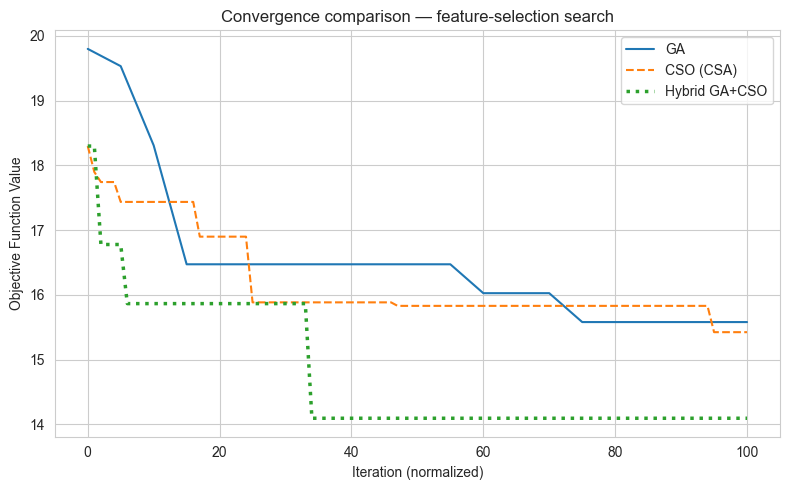

Final objective — GA: 15.578 | CSO: 15.422 | Hybrid GA+CSO: 14.092


In [24]:

def align_length(hist, target_len):
    '''Iteration counts differ (20 vs 100) -- resample onto a common x-axis for plotting.'''
    x_old = np.linspace(0, 1, len(hist))
    x_new = np.linspace(0, 1, target_len)
    return np.interp(x_new, x_old, hist)


max_len = max(len(ga_history), len(csa_history), len(hybrid_history))

plt.figure(figsize=(8, 5))
plt.plot(align_length(ga_history, max_len), label="GA", linestyle="-")
plt.plot(align_length(csa_history, max_len), label="CSO (CSA)", linestyle="--")
plt.plot(align_length(hybrid_history, max_len), label="Hybrid GA+CSO", linestyle=":", linewidth=2.5)
plt.xlabel("Iteration (normalized)")
plt.ylabel("Objective Function Value")
plt.title("Convergence comparison — feature-selection search")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Final objective — GA: {ga_history[-1]:.3f} | CSO: {csa_history[-1]:.3f} | Hybrid GA+CSO: {hybrid_history[-1]:.3f}")


In [ ]:
# NOTE: stability check across 5 random seeds (tidak ada di paper -- ditambahkan untuk
# verifikasi). TIDAK dipakai downstream (feature selection final tetap pakai hybrid_best_vec
# dari run tunggal sebelumnya), jadi aman untuk di-skip. Dengan budget paper-accurate
# (50/100 untuk CSA & Hybrid) ini makan waktu ~20-25 menit.
RUN_STABILITY_CHECK = False
TRIALS_CACHE_PATH = './outputs/feature_selection_seed_trials.csv'


def run_trial(seed):
    _, ga_obj, _ = genetic_algorithm(n_features, seed=seed)
    _, csa_obj, _ = cuckoo_search(n_features, seed=seed)
    _, hyb_obj, _ = hybrid_ga_cso(n_features, seed=seed)
    return ga_obj, csa_obj, hyb_obj


if RUN_STABILITY_CHECK:
    trials = [run_trial(seed) for seed in range(5)]
    trial_df = pd.DataFrame(trials, columns=["GA", "CSA", "Hybrid GA+CSO"])
    trial_df.index.name = "seed"
    trial_df.loc["mean"] = trial_df.iloc[:5].mean()
    trial_df.loc["std"] = trial_df.iloc[:5].std()
    os.makedirs(os.path.dirname(TRIALS_CACHE_PATH), exist_ok=True)
    trial_df.to_csv(TRIALS_CACHE_PATH)
    print(f"RUN_STABILITY_CHECK=True -> hasil baru disimpan ke {TRIALS_CACHE_PATH}")
elif os.path.exists(TRIALS_CACHE_PATH):
    trial_df = pd.read_csv(TRIALS_CACHE_PATH, index_col=0)
    print(f"RUN_STABILITY_CHECK=False -> memuat hasil cache dari {TRIALS_CACHE_PATH} "
          "(set True untuk menjalankan ulang, ~20-25 menit)")
else:
    trial_df = None
    print("RUN_STABILITY_CHECK=False dan belum ada cache tersimpan -> dilewati. "
          "Set True untuk menjalankan sekali (~20-25 menit); hasilnya akan tersimpan "
          "otomatis untuk run berikutnya.")

trial_df

,GA,CSA,Hybrid GA+CSO
seed,,,
0,15.818354,14.057407,16.526543
1,15.773210,15.728066,15.693210
2,17.103210,14.985021,16.235021
3,15.818354,15.331975,15.753786
4,16.636255,15.778354,16.174444
mean,16.229877,15.176165,16.076601
std,0.607269,0.703502,0.349398


In [44]:
import os
TRIALS_CACHE_PATH = './outputs/feature_selection_seed_trials.csv'
os.makedirs(os.path.dirname(TRIALS_CACHE_PATH), exist_ok=True)
trial_df.to_csv(TRIALS_CACHE_PATH)
print("Tersimpan:", TRIALS_CACHE_PATH)

Tersimpan: ./outputs/feature_selection_seed_trials.csv


## 9. Selected feature subsets — side by side

In [26]:

def selected_features(vec):
    mask = to_binary_mask(vec)
    return {f: bool(m) for f, m in zip(feature_cols, mask)}

summary = pd.DataFrame({
    "GA": selected_features(ga_best_vec),
    "CSO (CSA)": selected_features(csa_best_vec),
    "Hybrid GA+CSO": selected_features(hybrid_best_vec),
})
summary.loc["n_selected"] = summary.sum()
summary.loc["final_objective"] = [ga_history[-1], csa_history[-1], hybrid_history[-1]]
summary


,GA,CSO (CSA),Hybrid GA+CSO
age,0.000000,1.000000,0.000000
trestbps,0.000000,0.000000,0.000000
chol,0.000000,1.000000,0.000000
thalach,0.000000,0.000000,1.000000
oldpeak,0.000000,0.000000,0.000000
sex,0.000000,1.000000,0.000000
fbs,0.000000,1.000000,1.000000
exang,1.000000,0.000000,0.000000
cp_1.0,0.000000,1.000000,1.000000
cp_2.0,0.000000,1.000000,0.000000


## 10. Theoretical complexity (paper, Section VI-C)

In [27]:

# paper's Table 2 values -- now the same values actually used by the algorithms above
# (previously this cell only *printed* the paper's numbers while the real runs above
# used a much smaller ad-hoc budget; that mismatch is now fixed).
P_ga, G_ga = 10, 20
n_nests_csa, T_csa = 50, 100
P_hybrid, G_hybrid = 50, 100

print(f"GA complexity term:          P*G       = {P_ga * G_ga}")
print(f"CSA complexity term:         n*T       = {n_nests_csa * T_csa}")
print(f"Hybrid GA+CSO complexity:    P*G + n*I = {P_hybrid * G_hybrid} (dominant term)")
print(f"\nNumber of features in this dataset (n): {n_features}")


GA complexity term:          P*G       = 200
CSA complexity term:         n*T       = 5000
Hybrid GA+CSO complexity:    P*G + n*I = 5000 (dominant term)

Number of features in this dataset (n): 25


In [28]:
# Feature selection menggunakan Hybrid
hybrid_mask = to_binary_mask(hybrid_best_vec)

selected_feature_names = [
    f for f, m in zip(feature_cols, hybrid_mask) if m
]

X_train = X_train[:, hybrid_mask]
X_test = X_test[:, hybrid_mask]
y_train = y_train.copy()

print("Selected features:", selected_feature_names)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)

Selected features: ['thalach', 'fbs', 'cp_1.0', 'cp_4.0', 'restecg_0.0', 'restecg_2.0', 'slope_1.0', 'thal_6.0', 'thal_7.0', 'ca_0.0', 'ca_1.0']
X_train shape: (242, 11)
X_test shape: (61, 11)
y_train shape: (242,)


# Modeling

#### Random Forest

In [29]:
rf = RandomForestClassifier(
    n_estimators=194,
    max_depth=43,
    random_state=42
)

rf.fit(X_train, y_train)
rf_prob = rf.predict_proba(X_test)[:, 1]

#### CNN

In [30]:
cnn = Sequential([
    Conv1D(
        filters=34,
        kernel_size=2,
        activation='relu',
        input_shape=(X_train.shape[1], 1)
    ),

    MaxPooling1D(pool_size=2),

    Flatten(),

    Dense(50, activation='relu'),

    Dense(1, activation='sigmoid')
])

cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
X_train_cnn = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test_cnn = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

In [32]:
cnn.fit(
    X_train_cnn,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy: 0.6943 - loss: 0.6751 - val_accuracy: 0.6122 - val_loss: 0.6685
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7461 - loss: 0.6467 - val_accuracy: 0.6531 - val_loss: 0.6502
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7668 - loss: 0.6250 - val_accuracy: 0.7551 - val_loss: 0.6301
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7876 - loss: 0.6037 - val_accuracy: 0.7347 - val_loss: 0.6087
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7979 - loss: 0.5810 - val_accuracy: 0.7347 - val_loss: 0.5881
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8238 - loss: 0.5568 - val_accuracy: 0.7755 - val_loss: 0.5679
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8135 - loss: 0.5321 - val_accuracy: 0.7959 - val_loss: 0.5486
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8135 - loss: 0.5081 - val_accuracy: 0.7959 - val_loss: 0.5298


In [33]:
cnn_prob = cnn.predict(X_test_cnn).ravel()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


#### Ensemble RF + CNN

In [34]:
# PATCH: paper (Sec. IV-B) specifies majority voting between RF and CNN, not a plain
# 0.5/0.5 probability average. With two models a vote can tie; ties are broken using the
# average probability (same convention as main(6)).
def majority_vote(p_rf, p_cnn, thr=0.5):
    y_rf = (p_rf >= thr).astype(int)
    y_cnn = (p_cnn >= thr).astype(int)
    votes = y_rf + y_cnn
    avg = 0.5 * p_rf + 0.5 * p_cnn
    pred = np.where(votes == 2, 1, np.where(votes == 0, 0, (avg >= thr).astype(int)))
    return pred, avg

ensemble_pred, ensemble_prob = majority_vote(rf_prob, cnn_prob)


In [35]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

accuracy = accuracy_score(y_test, ensemble_pred)
precision = precision_score(y_test, ensemble_pred)
recall = recall_score(y_test, ensemble_pred)
f1 = f1_score(y_test, ensemble_pred)
roc_auc = roc_auc_score(y_test, ensemble_prob)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    ensemble_pred
).ravel()

specificity = tn / (tn + fp)

In [36]:
from sklearn.metrics import classification_report

rf_pred = (rf_prob >= 0.5).astype(int)
cnn_pred = (cnn_prob >= 0.5).astype(int)

def eval_model(name, y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1_ = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    spec = tn / (tn + fp)
    print(f"--- {name} ---")
    print(f"Accuracy    : {acc:.4f}")
    print(f"Precision   : {prec:.4f}")
    print(f"Recall      : {rec:.4f}")
    print(f"F1-score    : {f1_:.4f}")
    print(f"Specificity : {spec:.4f}")
    print(f"ROC AUC     : {auc:.4f}")
    print()
    return {"model": name, "accuracy": acc, "precision": prec, "recall": rec,
            "f1": f1_, "specificity": spec, "roc_auc": auc}

results = []
results.append(eval_model("Random Forest", y_test, rf_pred, rf_prob))
results.append(eval_model("CNN", y_test, cnn_pred, cnn_prob))
results.append(eval_model("Ensemble RF + CNN", y_test, ensemble_pred, ensemble_prob))

results_df = pd.DataFrame(results).set_index("model")
results_df

--- Random Forest ---
Accuracy    : 0.8361
Precision   : 0.8000
Recall      : 0.8571
F1-score    : 0.8276
Specificity : 0.8182
ROC AUC     : 0.9199

--- CNN ---
Accuracy    : 0.8361
Precision   : 0.8000
Recall      : 0.8571
F1-score    : 0.8276
Specificity : 0.8182
ROC AUC     : 0.8950

--- Ensemble RF + CNN ---
Accuracy    : 0.8525
Precision   : 0.8276
Recall      : 0.8571
F1-score    : 0.8421
Specificity : 0.8485
ROC AUC     : 0.9199



,accuracy,precision,recall,f1,specificity,roc_auc
model,,,,,,
Random Forest,0.836066,0.800000,0.857143,0.827586,0.818182,0.919913
CNN,0.836066,0.800000,0.857143,0.827586,0.818182,0.895022
Ensemble RF + CNN,0.852459,0.827586,0.857143,0.842105,0.848485,0.919913


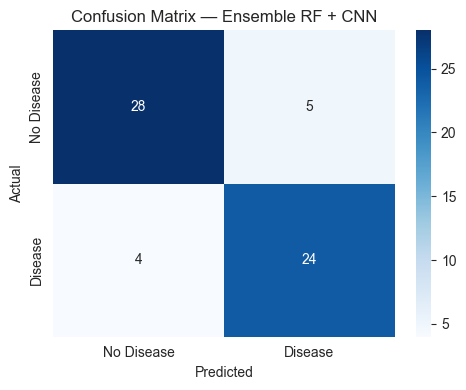

              precision    recall  f1-score   support

  No Disease       0.88      0.85      0.86        33
     Disease       0.83      0.86      0.84        28

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



In [37]:
cm = confusion_matrix(y_test, ensemble_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Ensemble RF + CNN")
plt.tight_layout()
plt.show()

print(classification_report(y_test, ensemble_pred,
                             target_names=["No Disease", "Disease"]))

## Hyperparameter Tuning

In [38]:
ENS_HP_BOUNDS = {
    # Random Forest
    "rf_n_estimators": (10, 300),
    "rf_max_depth": (2, 50),
    "rf_min_samples_split": (2, 20),
    "rf_min_samples_leaf": (1, 10),
    "rf_max_features": (0.1, 1.0),
    # CNN
    "cnn_filters": (8, 64),
    "cnn_kernel_size": (2, 4),
    "cnn_dense_units": (16, 128),
    "cnn_learning_rate": (1e-4, 1e-2),
    "cnn_epochs": (10, 50),
    "cnn_batch_size": (16, 64),
}
ENS_HP_NAMES = list(ENS_HP_BOUNDS.keys())
ENS_HP_INT = {
    "rf_n_estimators", "rf_max_depth", "rf_min_samples_split", "rf_min_samples_leaf",
    "cnn_filters", "cnn_kernel_size", "cnn_dense_units", "cnn_epochs", "cnn_batch_size",
}
N_ENS_HP = len(ENS_HP_NAMES)


def decode_ensemble_hyperparams(vec):
    '''Map GA vector [-1,1] -> (rf_params dict, cnn_params dict).'''
    scaled01 = (np.clip(vec, -1, 1) + 1) / 2
    raw = {}
    for name, val01 in zip(ENS_HP_NAMES, scaled01):
        lo, hi = ENS_HP_BOUNDS[name]
        value = lo + val01 * (hi - lo)
        raw[name] = int(round(value)) if name in ENS_HP_INT else float(value)

    rf_params = {
        "n_estimators": raw["rf_n_estimators"],
        "max_depth": raw["rf_max_depth"],
        "min_samples_split": raw["rf_min_samples_split"],
        "min_samples_leaf": raw["rf_min_samples_leaf"],
        "max_features": raw["rf_max_features"],
    }
    cnn_params = {
        "filters": raw["cnn_filters"],
        "kernel_size": raw["cnn_kernel_size"],
        "dense_units": raw["cnn_dense_units"],
        "learning_rate": raw["cnn_learning_rate"],
        "epochs": raw["cnn_epochs"],
        "batch_size": raw["cnn_batch_size"],
    }
    return rf_params, cnn_params

In [39]:
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import StratifiedKFold

def build_cnn(n_features, filters, kernel_size, dense_units, learning_rate):
    model = Sequential([
        Conv1D(filters=filters, kernel_size=kernel_size, activation='relu',
               input_shape=(n_features, 1)),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(dense_units, activation='relu'),
        Dense(1, activation='sigmoid'),
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model


# Stratified 3-fold CV pada training set saja (konsisten dengan fitness function feature selection)
_ens_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RNG_SEED)
_ens_fitness_cache = {}

def objective_ensemble_hyperparams(vec) -> float:
    '''Lower is better -- 100 * (1 - mean akurasi ensemble across StratifiedKFold CV pada training set).'''
    rf_params, cnn_params = decode_ensemble_hyperparams(vec)
    key = (tuple(sorted(rf_params.items())), tuple(sorted(cnn_params.items())))
    if key in _ens_fitness_cache:
        return _ens_fitness_cache[key]

    fold_accs = []
    for train_idx, val_idx in _ens_cv.split(X_train, y_train):
        Xtr_fold, Xval_fold = X_train[train_idx], X_train[val_idx]
        ytr_fold, yval_fold = y_train[train_idx], y_train[val_idx]

        rf_ = RandomForestClassifier(random_state=RNG_SEED, n_jobs=1, **rf_params)
        rf_.fit(Xtr_fold, ytr_fold)
        rf_val_prob = rf_.predict_proba(Xval_fold)[:, 1]

        Xtr_fold_cnn = Xtr_fold.reshape(Xtr_fold.shape[0], Xtr_fold.shape[1], 1)
        Xval_fold_cnn = Xval_fold.reshape(Xval_fold.shape[0], Xval_fold.shape[1], 1)

        cnn_ = build_cnn(Xtr_fold.shape[1], cnn_params["filters"], cnn_params["kernel_size"],
                          cnn_params["dense_units"], cnn_params["learning_rate"])
        cnn_.fit(Xtr_fold_cnn, ytr_fold, epochs=cnn_params["epochs"],
                  batch_size=cnn_params["batch_size"], verbose=0)
        cnn_val_prob = cnn_.predict(Xval_fold_cnn, verbose=0).ravel()

        ens_val_prob = 0.5 * rf_val_prob + 0.5 * cnn_val_prob
        ens_val_pred = (ens_val_prob >= 0.5).astype(int)
        fold_accs.append(accuracy_score(yval_fold, ens_val_pred))

    mean_acc = float(np.mean(fold_accs))
    obj = 100.0 * (1 - mean_acc)
    _ens_fitness_cache[key] = obj
    return obj


In [40]:
ens_hp_best_vec, ens_hp_best_obj, ens_hp_history = genetic_algorithm(
    N_ENS_HP,
    pop_size=8,
    generations=10,
    objective_fn=objective_ensemble_hyperparams,
    seed=RNG_SEED,
)

best_rf_params_ens, best_cnn_params_ens = decode_ensemble_hyperparams(ens_hp_best_vec)
print(f"Best validation objective: {ens_hp_best_obj:.3f}")
print("Best RF params  :", best_rf_params_ens)
print("Best CNN params :", best_cnn_params_ens)

c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using a

Best validation objective: 14.475
Best RF params  : {'n_estimators': 211, 'max_depth': 15, 'min_samples_split': 12, 'min_samples_leaf': 5, 'max_features': 0.1}
Best CNN params : {'filters': 39, 'kernel_size': 2, 'dense_units': 73, 'learning_rate': 0.006353477551308443, 'epochs': 30, 'batch_size': 33}


In [41]:
rf_tuned_ens = RandomForestClassifier(random_state=RNG_SEED, n_jobs=1, **best_rf_params_ens)
rf_tuned_ens.fit(X_train, y_train)
rf_tuned_ens_prob = rf_tuned_ens.predict_proba(X_test)[:, 1]

X_train_cnn_full = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn_full = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

cnn_tuned_ens = build_cnn(X_train.shape[1], best_cnn_params_ens["filters"],
                           best_cnn_params_ens["kernel_size"],
                           best_cnn_params_ens["dense_units"],
                           best_cnn_params_ens["learning_rate"])
cnn_tuned_ens.fit(X_train_cnn_full, y_train,
                   epochs=best_cnn_params_ens["epochs"],
                   batch_size=best_cnn_params_ens["batch_size"],
                   validation_split=0.2, verbose=0)
cnn_tuned_ens_prob = cnn_tuned_ens.predict(X_test_cnn_full, verbose=0).ravel()

ensemble_tuned_prob = 0.5 * rf_tuned_ens_prob + 0.5 * cnn_tuned_ens_prob
ensemble_tuned_pred = (ensemble_tuned_prob >= 0.5).astype(int)

c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
results.append(eval_model("Ensemble Tuned (GA)", y_test, ensemble_tuned_pred, ensemble_tuned_prob))
results_df = pd.DataFrame(results).set_index("model")
results_df

--- Ensemble Tuned (GA) ---
Accuracy    : 0.8525
Precision   : 0.8276
Recall      : 0.8571
F1-score    : 0.8421
Specificity : 0.8485
ROC AUC     : 0.9199



,accuracy,precision,recall,f1,specificity,roc_auc
model,,,,,,
Random Forest,0.836066,0.800000,0.857143,0.827586,0.818182,0.919913
CNN,0.836066,0.800000,0.857143,0.827586,0.818182,0.895022
Ensemble RF + CNN,0.852459,0.827586,0.857143,0.842105,0.848485,0.919913
Ensemble Tuned (GA),0.852459,0.827586,0.857143,0.842105,0.848485,0.919913


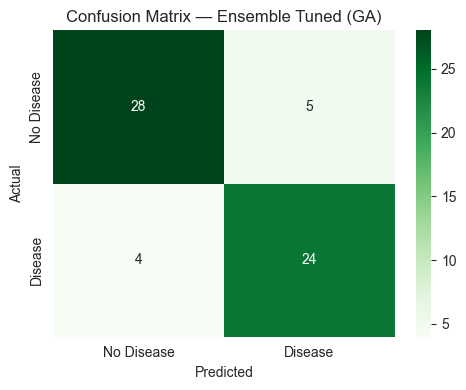

              precision    recall  f1-score   support

  No Disease       0.88      0.85      0.86        33
     Disease       0.83      0.86      0.84        28

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



In [43]:
cm_tuned = confusion_matrix(y_test, ensemble_tuned_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_tuned, annot=True, fmt="d", cmap="Greens",
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Ensemble Tuned (GA)")
plt.tight_layout()
plt.show()

print(classification_report(y_test, ensemble_tuned_pred,
                             target_names=["No Disease", "Disease"]))

In [45]:
print("RF params default :", RF_PARAMS if 'RF_PARAMS' in dir() else {'n_estimators':194,'max_depth':43})
print("RF params tuned    :", best_rf_params_ens)
print("CNN params tuned   :", best_cnn_params_ens)
print()
print("GA history (objective per generasi):", ens_hp_history)
print()
print("rf_prob == rf_tuned_ens_prob (semua sama)?  ", np.allclose(rf_prob, rf_tuned_ens_prob))
print("cnn_prob == cnn_tuned_ens_prob (semua sama)?", np.allclose(cnn_prob, cnn_tuned_ens_prob))
print("ensemble_prob == ensemble_tuned_prob?       ", np.allclose(ensemble_prob, ensemble_tuned_prob))
print("max |ensemble_prob - ensemble_tuned_prob|   :", np.max(np.abs(ensemble_prob - ensemble_tuned_prob)))

RF params default : {'n_estimators': 194, 'max_depth': 43}
RF params tuned    : {'n_estimators': 211, 'max_depth': 15, 'min_samples_split': 12, 'min_samples_leaf': 5, 'max_features': 0.1}
CNN params tuned   : {'filters': 39, 'kernel_size': 2, 'dense_units': 73, 'learning_rate': 0.006353477551308443, 'epochs': 30, 'batch_size': 33}

GA history (objective per generasi): [np.float64(15.709876543209889), np.float64(15.709876543209889), np.float64(15.709876543209889), np.float64(15.709876543209889), np.float64(15.709876543209889), np.float64(14.89197530864198), np.float64(14.876543209876536), np.float64(14.480452674897126), np.float64(14.480452674897126), np.float64(14.480452674897126), np.float64(14.475308641975316)]

rf_prob == rf_tuned_ens_prob (semua sama)?   False
cnn_prob == cnn_tuned_ens_prob (semua sama)? False
ensemble_prob == ensemble_tuned_prob?        False
max |ensemble_prob - ensemble_tuned_prob|   : 0.19861287931503302


In [46]:
from scipy.stats import spearmanr

print("Spearman corr rf_prob vs ensemble_prob       :", spearmanr(rf_prob, ensemble_prob).correlation)
print("Spearman corr rf_prob vs ensemble_tuned_prob :", spearmanr(rf_prob, ensemble_tuned_prob).correlation)
print("Spearman corr cnn_prob vs cnn_tuned_ens_prob :", spearmanr(cnn_prob, cnn_tuned_ens_prob).correlation)
print()
print("CNN AUC (default) :", roc_auc_score(y_test, cnn_prob))
print("CNN AUC (tuned)   :", roc_auc_score(y_test, cnn_tuned_ens_prob))
print()
print("Jumlah sample yang prediksi biner-nya beda antara RF-only vs Ensemble Tuned:",
      np.sum((rf_prob >= 0.5).astype(int) != (ensemble_tuned_prob >= 0.5).astype(int)))

Spearman corr rf_prob vs ensemble_prob       : 0.9458791312210612
Spearman corr rf_prob vs ensemble_tuned_prob : 0.8878046331596791
Spearman corr cnn_prob vs cnn_tuned_ens_prob : 0.9772078265468006

CNN AUC (default) : 0.895021645021645
CNN AUC (tuned)   : 0.893939393939394

Jumlah sample yang prediksi biner-nya beda antara RF-only vs Ensemble Tuned: 5


Penjelasan kenapa hasil prediksi dan akurasi antara model tanpa tuning & dengan tuning sama:
GA hyperparameter tuning berhasil menemukan konfigurasi RF & CNN yang secara numerik berbeda signifikan dari default (objective turun 15.71→14.48), tapi perbedaan pada ensemble_prob (probabilitas mentah, max delta ≈0.199) tidak pernah menyeberangi decision threshold 0.5 pada sample manapun. Akibatnya, prediksi biner (dan seluruh metrik yang bergantung padanya: accuracy, precision, recall, f1, specificity) identik. AUC-nya juga kebetulan sama karena AUC hanya sensitif terhadap urutan relatif pasangan (positif, negatif) yang saling menyilang — bukan urutan keseluruhan sample — dan pergeseran probabilitas dari tuning tidak mengubah satupun pasangan silang tersebut. Root cause-nya: dataset kecil (n≈303, test≈61) dan fitur yang sudah direduksi membuat RF cepat "saturasi" (performanya plateau begitu kompleksitas model cukup), sementara CNN konsisten lemah (AUC ~0.894-0.895) di semua konfigurasi karena data terlalu sedikit untuk Conv1D benar-benar belajar pola tambahan. Jadi tuning "jalan" secara matematis (mencari hyperparameter dengan objective lebih rendah), tapi ruang perbaikan yang tersedia di data ini sudah sempit duluan sebelum tuning dimulai.